# UMAP Algorithm Implementation from Scratch

This notebook explores the math behind **UMAP (Uniform Manifold Approximation and Projection)** by building it step-by-step from scratch. 

> 🤖 **AI-Assisted** — Imports and setup.


In [ ]:
import numpy as np 
import pandas as pd
from scipy.spatial.distance import cdist
import random 

# LLM as I am not familiar with these packages
from scipy.sparse.csgraph import laplacian
from scipy.sparse.linalg import eigsh
from scipy.optimize import curve_fit


## 1. Finding Local Bandwidth ($\sigma$)

UMAP models local data manifolds. To handle varying densities, each point gets its own distance scale ($\sigma_i$) and local connectivity ($\rho_i$, distance to nearest neighbor). 

We find $\sigma_i$ by performing a binary search such that the sum of the fuzzy memberships for the $k$ nearest neighbors equals $\log_2(k)$. 

The fuzzy membership function is:
$$ v = \exp\left( -\frac{\max(0, d - \rho_i)}{\sigma_i} \right) $$

> ✍️ **My Work** — Wrote the binary search algorithm to solve for $\sigma_i$.


In [231]:
def binary_search_sigma(distances, k):
    epsilon = 1e-7
    sigma = 1.0
    low =0.0 
    high = 100.0 # harcoded cap
    rho = np.min(distances)
    goal = np.log2(k)
    for _ in range(100): # cap on iterations
        v = np.exp(-np.maximum(0, distances - rho)/sigma)
        sum_v = np.sum(v)
        if(abs(sum_v -goal) < epsilon ): 
            break
        if(sum_v > goal): 
            high = sigma
        else:
            low = sigma
        sigma = (low+high)/2.0
    return sigma,rho

## 2. Nearest Neighbors

To construct the graph, we need the $k$ nearest neighbors for each point. For simplicity and proof of concept, we calculate the full pairwise distance matrix and extract the top $k$.

> ✍️ **My Work** — Distance matrix and k-NN extraction.


In [ ]:

def closest_k(k, df, metric): 
    """
    brute force calculates all distances then takes least k 
    this is not optimal but only done for proof of concept 
    return the indices of top k points and the their values
    """
    distances = pd.DataFrame(cdist(df.values, df.values, metric=metric), index=df.index, columns=df.index)

    #ignores same point distance 
    closest_k = np.argsort(distances, axis =1)[: ,1:k+1]
    closest_k =  pd.DataFrame(closest_k)
    closest_k_vals = pd.DataFrame( index = closest_k.index, columns=closest_k.columns)
    for i in range(len(closest_k_vals.values)):
        closest_k_vals.iloc[i, :] = distances.loc[closest_k.iloc[i]][i]
    
    return pd.DataFrame(closest_k), closest_k_vals, distances
    

In [ ]:

data = np.random.uniform(0, 10, size=(N, N))
df = pd.DataFrame(data)

ck,ck_v, V= closest_k(K, df, "euclidean")



      0    1    2    3    4    5    6    7    8    9    10   11   12   13   14
0    277  223   41  120   62   27  122  101   23  113   78   84    3   85  274
1    242  211   17   61   42   11  236  177    7  284  220  198  221   48   77
2    259  202  284   87   35  153  227    4  191  129  260  157  231  241  194
3    226  228  113  153  212  273   49   97   91   59  179  257   13  274  298
4    193   69  273  116  287  141   70  228  177   92  282  212  221  196   16
..   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...
295  224  177  180  259   56  228  129  257  203   96  113  107  238  172  273
296  253   87  106  241  103  129   59  195  259  221  284  185  141   18  154
297  260  198   48  109  132   45   87  221   60   72  286   97  211   23   24
298  172  211  234  212   56  151  129   11  188  182    3  268  198  249  283
299  212  259   13  264  120  221  115  131  102   17  227   49  200  141   26

[300 rows x 15 columns]
            0          1   

## 3. Computing $\sigma_i$ and $\rho_i$ for all points

Iterate through every point's $k$-NN distances and use our binary search function to find its local scaling parameters.

> ✍️ **My Work** — Iteration logic.


In [ ]:
def find_sigmas(ck_v,k):
    sigmas = []
    rhos = []
    for i in range(len(ck_v.values)): 
        distances = ck_v.iloc[i].astype(float)
        sigma, rho = binary_search_sigma(distances, K)
        sigmas.append(sigma)
        rhos.append(rho)

    return sigmas, rhos
 

## 4. Fuzzy Simplicial Set (High-Dimensional Graph)

We calculate the directed fuzzy edge weights between points $i$ and $j$. The weight represents the probability that a simplex exists between them, scaled locally:

$$ p_{i|j} = \exp\left( -\frac{\max(0, d(x_i, x_j) - \rho_i)}{\sigma_i} \right) $$

> ✍️ **My Work** — Implementation of the high-dimensional fuzzy membership probabilities.


In [ ]:
def find_fuzzy_membership(ck_v, sigmas, rhos, k):
    fuzzy_membership =  pd.DataFrame(0.0, index=ck_v.index, columns=ck_v.columns)
    for i in range(len(fuzzy_membership.values)):
        for j in range(k):
                fuzzy_membership.iloc[i, j] = np.exp(-(ck_v.iloc[i,j]-rhos[i])/sigmas[i])
    return fuzzy_membership



,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,1.0,0.413252,0.286812,0.277948,0.277482,0.220565,0.204181,0.191408,0.188599,0.170270,0.152470,0.146525,0.128297,0.125118,0.123963
1,1.0,0.404638,0.315590,0.306449,0.284728,0.211494,0.203841,0.195150,0.172576,0.157164,0.146285,0.131089,0.129028,0.126072,0.122788
2,1.0,0.417430,0.339554,0.336983,0.218270,0.216854,0.201876,0.170717,0.169754,0.167196,0.162313,0.151295,0.131556,0.113980,0.109112
3,1.0,0.438332,0.429537,0.332236,0.314133,0.257233,0.257127,0.219479,0.138459,0.113787,0.099605,0.096364,0.093253,0.061832,0.055514
4,1.0,0.777374,0.397995,0.269282,0.207692,0.193580,0.188520,0.173654,0.150989,0.118685,0.117649,0.113356,0.066537,0.066289,0.065289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1.0,0.392953,0.280804,0.250416,0.238587,0.227238,0.215158,0.209086,0.173539,0.168905,0.165272,0.160082,0.151121,0.146938,0.126792
296,1.0,0.340730,0.297807,0.243242,0.229384,0.228737,0.208500,0.190089,0.189744,0.187185,0.168587,0.162981,0.156094,0.155099,0.148714
297,1.0,0.684338,0.501522,0.405942,0.210498,0.173741,0.124609,0.115050,0.113385,0.106260,0.098589,0.097480,0.097446,0.091798,0.086231
298,1.0,0.775536,0.506197,0.308259,0.264779,0.216288,0.181804,0.105356,0.091950,0.087146,0.083682,0.083440,0.076540,0.070858,0.055056


## 5. Symmetrizing the Graph (Fuzzy Union)

The directed probabilities $p_{i|j}$ and $p_{j|i}$ are not equal because $\sigma_i \neq \sigma_j$. We make the graph undirected (symmetric) by taking the probabilistic fuzzy union:

$$ p_{ij} = p_{i|j} + p_{j|i} - p_{i|j} p_{j|i} $$

> ✍️ **My Work** — Fuzzy union matrix calculation.


In [ ]:
def fuzzy_union(fuzzy_membership, k, N):
    V = np.zeros((N,N))
    for i in range(N):
        for j in range(k):
            neighbor_idx = ck.iloc[i,j]
            V[i, neighbor_idx] =  fuzzy_membership.iloc[i,j]
    return V + V.T - V*V.T



array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

## 6. Low-Dimensional Distance Function

UMAP models the low-dimensional space using a family of curves similar to the Student t-distribution:
$$ q_{ij} = \frac{1}{1 + a \cdot d(y_i, y_j)^{2b}} $$

Instead of hardcoding $a$ and $b$, UMAP fits them to best approximate a piecewise function controlled by `min_dist`. We use `scipy.optimize.curve_fit` to find these parameters.

> ✍️ **My Work** — Hyperparameter curve fitting.


In [370]:

def find_a_b(min_dist =0.1):
    def smooth_t_std(x, a, b):
        return 1.0/ (1.0 + a *x**(2*b))
    x = np.linspace(0, 3, 300) 
    ideal_y = np.zeros(300)
    for i in range(len(x)):
        if x[i] <= min_dist: 
            ideal_y[i] = 1
        else: 
            ideal_y[i] = np.exp(-(x[i] - min_dist))
    (a, b), _  = curve_fit(smooth_t_std, x, ideal_y)
    return a,b 





## 7. Spectral Initialization

To give the optimization a good starting point, we use Laplacian Eigenmaps (Spectral Embedding) rather than purely random coordinates. This preserves global structure early on.

> 🤖 **AI-Assisted** — Spectral initialization using `scipy.sparse`.


In [ ]:
def init_y(V, n_c =2): 
    L = laplacian(V, normed = True)
    e_val, e_vec = eigsh(L, k = n_c +1 )
    Y_init= e_vec[: , 1:]
    return Y_init



## 8. Optimization (SGD)

We optimize the low-dimensional embeddings $Y$ to minimize the cross-entropy between the high-dimensional graph ($V$) and the low-dimensional graph ($Q$).

This results in two forces applied via SGD:
- **Attractive Force**: Pulls connected points closer.
- **Repulsive Force**: Pushes a randomly sampled point further away (Negative Sampling).

> ✍️ **My Work** — Implemented the attractive and repulsive gradient updates.


In [373]:

def training_loop(EPOCHS, N, lr, Y, a, b):
    for e in range(EPOCHS):
        for i in range(N): 
            for j in range(N): 
                if V[i,j]>0 and random.random() <V[i,j]: 
                    lr = lr * (1 - (e / EPOCHS))
                    d_attr = np.linalg.norm(Y[i]- Y[j])
                    grad_attractive = -2*a*b * (d_attr**2)*(b-1) / (1 +a*d_attr**(2*b)) * (Y[i] - Y[j])
                    Y[i] = Y[i] + lr*grad_attractive
                    Y[j] = Y[j]- lr*grad_attractive
                    k = int(random.random()*N) 
                    d_rep = np.linalg.norm(Y[i]- Y[k])
                    grad_repulsive = 2*b / ( ( 1e-7 +  d_rep**2)* (1+ a*d_rep**(2*b))) *(Y[i] - Y[k])                
                    Y[i] = Y[i] + lr*grad_repulsive

    



Initial Y


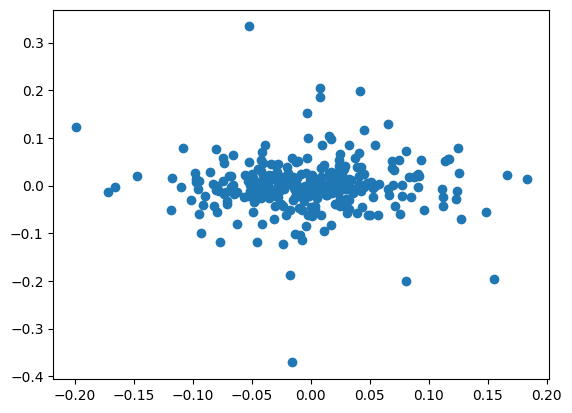

Final Y


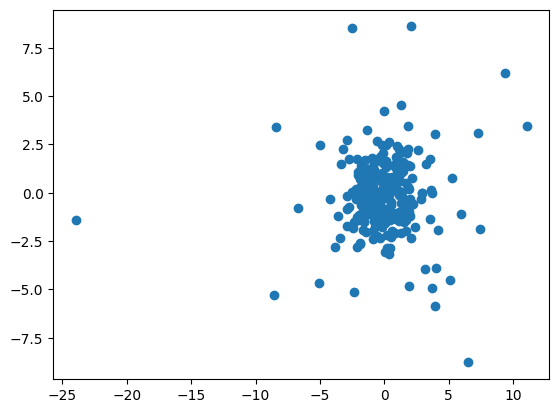

In [376]:
def umap(df, K=15 ,n_c = 2 ,min_dist =0.1, metric = "euclidean", epochs = 500, lr= 1e-1):
    N = len(df.values)
    def init_V(df, metric): 
        ck,ck_v, V= closest_k(K, df, metric)
        sigmas, rhos = find_sigmas(ck_v,K) 
        fuzzy_membership = find_fuzzy_membership(ck_v, sigmas, rhos, K)
        V = fuzzy_union(fuzzy_membership, K, N)
        return V
    V = init_V(df,metric)
    a,b = find_a_b(min_dist)
    Y = init_y(V, n_c)
    print("Initial Y")
    import matplotlib.pyplot as plt
    plt.scatter(Y[:, 0], Y[: , 1])
    plt.show()
    training_loop(epochs, N, lr, Y, a, b)
    print("Final Y")
    plt.scatter(Y[:, 0], Y[: , 1])
    
umap(df)